In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)

import librosa
from matplotlib import pyplot as plt

from modules.dataset import ICBHIFeaturesDataset, KAUHFeaturesDataset, CombinedFeaturesDataset, LungSoundFeaturesDataset
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    # "Bronchitis",
    "COPD",
    "Healthy",
    # "Heart Failure",
    # "LRTI",
    "Lung Fibrosis",
    # "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/data_preprocessed")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

feature_extractors = [
    STFT(),
    MelSpectrogram(n_mels=128),
    MFCC(n_mfcc=128),
    MFCCDelta(n_mfcc=128),
    Chroma(n_chroma=128),
    SpectralContrast(n_bands=4, fmin=50),
    CQT(n_bins=48, fmin=30, bins_per_octave=12),
    Phase(),
]

In [3]:
format = "npy"
extractor = STFT()
icbhi_dataset = ICBHIFeaturesDataset(DATA_FOLDER, "all", feature_extractors=extractor, feature_format=format, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head(10)

Dataset size: 3893 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label
0,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-000-005,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
1,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-005-010,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
2,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-010-015,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
3,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-015-020,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
4,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-000-005,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
5,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-005-010,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
6,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-010-015,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
7,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-015-020,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
8,ICBHI_2017,102_1b1_Ar_sc_Meditron_clip-000-005,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4
9,ICBHI_2017,102_1b1_Ar_sc_Meditron_clip-005-010,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4


Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npy
  Label: 7 (URTI)
  Feature shape: (1025, 216, 1)
  Feature dtype: float32
  Feature min value: -80.000
  Feature max value: 0.000
  Metadata: {'Source': 'ICBHI_2017', 'FileName': '101_1b1_Al_sc_Meditron_clip-000-005', 'Diagnosis': 'URTI', 'Age': 3.0, 'Sex': 'F', 'AdultBMI (kg/m2)': nan, 'ChildWheight (kg)': 19.0, 'ChildHeight (cm)': 99.0, 'PatientId': 'I101', 'RecordingIndex': '1b1', 'ChestLocation': 'Al', 'AcquisitionMode': 'sc', 'RecordingEquipment': 'Meditron', 'Label': 7}


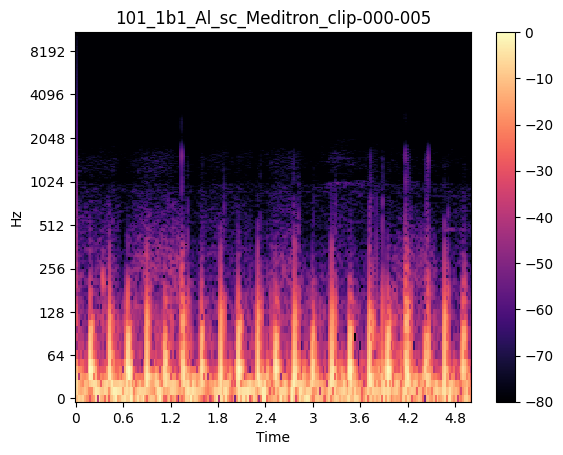

In [4]:
icbhi_dataset.unit_test(idx=0)

In [5]:
format = "npy"
extractor = Compose([
    MelSpectrogram(n_mels=128),
    MFCC(n_mfcc=128),
    Chroma(n_chroma=128),
])
icbhi_dataset = ICBHIFeaturesDataset(DATA_FOLDER, "all", feature_extractors=extractor, feature_format=format, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head(10)

Dataset size: 3893 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label
0,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-000-005,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
1,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-005-010,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
2,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-010-015,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
3,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-015-020,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
4,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-000-005,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
5,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-005-010,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
6,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-010-015,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
7,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-015-020,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
8,ICBHI_2017,102_1b1_Ar_sc_Meditron_clip-000-005,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4
9,ICBHI_2017,102_1b1_Ar_sc_Meditron_clip-005-010,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-480.07648..193.87114].


Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npy
  Label: 7 (URTI)
  Feature shape: (128, 216, 3)
  Feature dtype: float32
  Feature min value: -480.076
  Feature max value: 193.871
  Metadata: {'Source': 'ICBHI_2017', 'FileName': '101_1b1_Al_sc_Meditron_clip-000-005', 'Diagnosis': 'URTI', 'Age': 3.0, 'Sex': 'F', 'AdultBMI (kg/m2)': nan, 'ChildWheight (kg)': 19.0, 'ChildHeight (cm)': 99.0, 'PatientId': 'I101', 'RecordingIndex': '1b1', 'ChestLocation': 'Al', 'AcquisitionMode': 'sc', 'RecordingEquipment': 'Meditron', 'Label': 7}


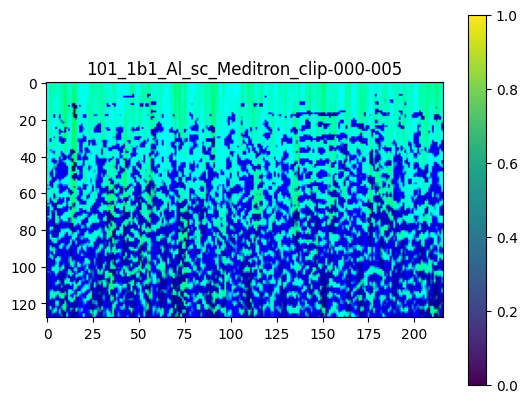

In [6]:
icbhi_dataset.unit_test(idx=0)

In [7]:
format = "npy"
extractor = Compose([
    STFT(),
    Phase(),
])
icbhi_dataset = ICBHIFeaturesDataset(DATA_FOLDER, "all", feature_extractors=extractor, feature_format=format, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head(10)

Dataset size: 3893 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label
0,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-000-005,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
1,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-005-010,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
2,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-010-015,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
3,ICBHI_2017,101_1b1_Al_sc_Meditron_clip-015-020,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
4,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-000-005,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
5,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-005-010,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
6,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-010-015,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
7,ICBHI_2017,101_1b1_Pr_sc_Meditron_clip-015-020,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7
8,ICBHI_2017,102_1b1_Ar_sc_Meditron_clip-000-005,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4
9,ICBHI_2017,102_1b1_Ar_sc_Meditron_clip-005-010,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4


In [8]:
icbhi_dataset.unit_test(idx=0)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npy
  Label: 7 (URTI)
  Feature shape: (1025, 216, 2)
  Feature dtype: float32
  Feature min value: -80.000
  Feature max value: 3.142
  Metadata: {'Source': 'ICBHI_2017', 'FileName': '101_1b1_Al_sc_Meditron_clip-000-005', 'Diagnosis': 'URTI', 'Age': 3.0, 'Sex': 'F', 'AdultBMI (kg/m2)': nan, 'ChildWheight (kg)': 19.0, 'ChildHeight (cm)': 99.0, 'PatientId': 'I101', 'RecordingIndex': '1b1', 'ChestLocation': 'Al', 'AcquisitionMode': 'sc', 'RecordingEquipment': 'Meditron', 'Label': 7}
